# Task 8.1D: Sydney Housing Price Prediction and Decision Support System
**SIT307 Machine Learning, ML Mini Project**

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")   # hide library warnings so the outputs are easier to read

SUBURBS = ["Mount Druitt", "Cabramatta", "Vaucluse"]   # cheapest to most expensive

---
## Part 1: Problem Definition and Data Collection

### 1.1 The problem
This is a **supervised regression problem**. The input is a property's details (suburb, type, bedrooms, bathrooms, car spaces, land size, extra features and the agent's description), and the output is a number: the **sale price**.

I use **sold** prices, not asking prices, because that's what buyers actually paid.

### 1.2 Choosing the three suburbs
I picked three suburbs I would personally consider buying in, and they're **very different markets**:

| | **Mount Druitt** (2770) | **Cabramatta** (2166) | **Vaucluse** (2030) |
|---|---|---|---|
| Where | Outer western Sydney, about 38 km from the CBD | South-western Sydney, about 25 km from the CBD | Eastern Suburbs on the harbour, about 6.5 km from the CBD |
| Type of market | Entry level: first-home buyers and investors | Mid range: families and investors | Prestige / luxury |
| What drives value | Big blocks, granny-flat potential, rental yield, train station and Westfield | Train station, busy Southeast Asian shopping and food centre, higher-density zoning near the centre | Harbour and ocean views, beaches, very limited land, top private schools |
| Why I'd buy here | The most affordable way for me to own land in Sydney | A big Southeast Asian community that feels familiar to me (I'm from Cambodia), good transport and good value | My long-term "dream" goal, and it shows the top end of the market |

Having a cheap, a middle and a very expensive suburb makes the problem harder, but also more realistic. The model has to learn that the **same house can be worth very different amounts depending on where it is**. That's exactly what an agency covering several areas needs.

### 1.3 How suburb features could affect price
- **Location** should matter most. In Sydney, most of a property's value is the land, and land near the city and the water costs much more. A 4-bedroom house in Vaucluse should cost several times more than a similar one in Mount Druitt.
- **Property type** matters because a house comes with its own land, while a unit or townhouse (strata) shares the land with other owners.
- **Size** (bedrooms, bathrooms, car spaces, land) adds value everywhere, but an extra bedroom is probably worth more in an expensive suburb.
- **Suburb-specific things** are different in each place: views in Vaucluse, being close to the station in Cabramatta, and big blocks and granny flats in Mount Druitt.

### 1.4 The collected dataset
I opened each sold listing on realestate.com.au or domain.com.au and typed the details into `Sydney_Housing_Data.xlsx` by hand. For each property I recorded the sale price (target), sale date, sale method, property type, bedrooms, bathrooms, car spaces, land size, building size, year built, six Yes/No features (pool, air con, renovated, views, study, outdoor space), the agency and the full **agent description** (text data). I used a *Notes* column to record anything unusual.

In [80]:
df = pd.read_excel("Sydney_Housing_Data.xlsx")

# shorter column names so the code is easier to read
df = df.rename(columns={"Sale Price ($)": "Price", "Sale Date": "SaleDate", "Property Type": "Type",
                        "Car Spaces": "Cars", "Land Size (m²)": "Land", "Building Size (m²)": "Building",
                        "Year Built": "YearBuilt", "Sale Method": "Method", "Agent Description": "Description"})

print("Number of properties:", len(df))
print()
print(df["Suburb"].value_counts())
print()
pd.crosstab(df["Suburb"], df["Type"], margins=True)

Number of properties: 101

Suburb
Cabramatta      36
Vaucluse        34
Mount Druitt    31
Name: count, dtype: int64



Type,House,Semi/Duplex,Townhouse,Unit/Apartment,Villa,All
Suburb,,,,,,
Cabramatta,12,1,2,21,0,36
Mount Druitt,13,0,5,11,2,31
Vaucluse,17,0,2,15,0,34
All,42,1,9,47,2,101


In [81]:
# How much information is missing in each column?
missing = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(1)
missing_table = pd.DataFrame({"missing": missing, "percent": missing_percent})
missing_table[missing_table["missing"] > 0]

,missing,percent
Cars,6,5.9
Land,64,63.4
Building,84,83.2
YearBuilt,99,98.0
Agency,13,12.9
Notes,50,49.5


In [82]:
# Land size: units and townhouses don't have their own land, so check houses separately
houses = df[df["Type"].isin(["House", "Semi/Duplex"])]
print("Houses with no land size recorded (%):")
print((houses.groupby("Suburb")["Land"].apply(lambda s: s.isna().mean()) * 100).round(0))
print()
print("Sale method 'Not stated' (%):", round((df["Method"] == "Not stated").mean() * 100, 1))
print()
print("Sale dates collected per suburb:")
df.groupby("Suburb")["SaleDate"].agg(["min", "max"])

Houses with no land size recorded (%):
Suburb
Cabramatta      15.0
Mount Druitt    23.0
Vaucluse        24.0
Name: Land, dtype: float64

Sale method 'Not stated' (%): 59.4

Sale dates collected per suburb:


,min,max
Suburb,,
Cabramatta,2025-10-28,2026-09-30
Mount Druitt,2026-05-07,2026-09-21
Vaucluse,2025-05-08,2026-09-24


### 1.5 Data quality, challenges, bias and limitations

**Overall quality.** The dataset meets the brief: **101 sold properties** (Mount Druitt 31, Cabramatta 36, Vaucluse 34). Price, sale date, type, bedrooms and bathrooms are complete for every property, so the most important information is all there.

**Missing information**
- **Year built (98% missing) and building size (83% missing)** are hardly ever shown on listing pages, so I can't use them.
- **Land size is 63% missing**, but most of that is expected: units and townhouses don't have their own land. For houses only, 15–24% are missing.
- **Sale method** is "Not stated" for 59% of sales, so it's too incomplete to use.
- The Yes/No features came from reading the description. A "No" often means "the agent didn't mention it", not "the property doesn't have it".

**Challenges during collection**
- Copying details by hand from two websites with different layouts was slow, and it's easy to make mistakes. Some pages ended up pasted 2–3 times in my raw text file, and some properties appeared on both websites, so I had to remove the duplicates.
- Many sales say "price withheld" or "contact agent", so I couldn't use them.
- I found one data-entry mistake: **ID 79** (a Cabramatta unit) has the listing link of a different property. Its other details match the Cabramatta listing, so I kept it.
- A few sales were **more than one dwelling sold together** (ID 1: two houses sold as a development site; ID 35: four apartments; ID 39: two dwellings). These aren't normal single-home sales.

**Possible bias**
- **Selection bias:** withheld prices are more common for expensive homes, so the very top of the Vaucluse market is probably under-represented.
- **Time bias:** the Vaucluse sales go back to May 2025, but the Mount Druitt sales only start in May 2026. Some of the difference between suburbs could be timing.
- **Marketing bias:** agent descriptions are written to sell, so they highlight the good things and leave out the bad ones (busy road, poor condition).

**Limitations**
- About 100 properties across 3 suburbs and 5 property types is small. Some groups have only 13–17 properties.
- The model **only knows these three suburbs**, so it shouldn't be used anywhere else.
- Prices range from \$310k to \$22.4M, so a few very expensive homes will dominate any error measured in dollars.

**For the agent:** the tool will be most reliable for common property types and less reliable for rare, very expensive homes, because that's where we have the fewest examples.

---
## Part 2: Data Understanding and Feature Engineering

### 2.1 How are sale prices distributed?

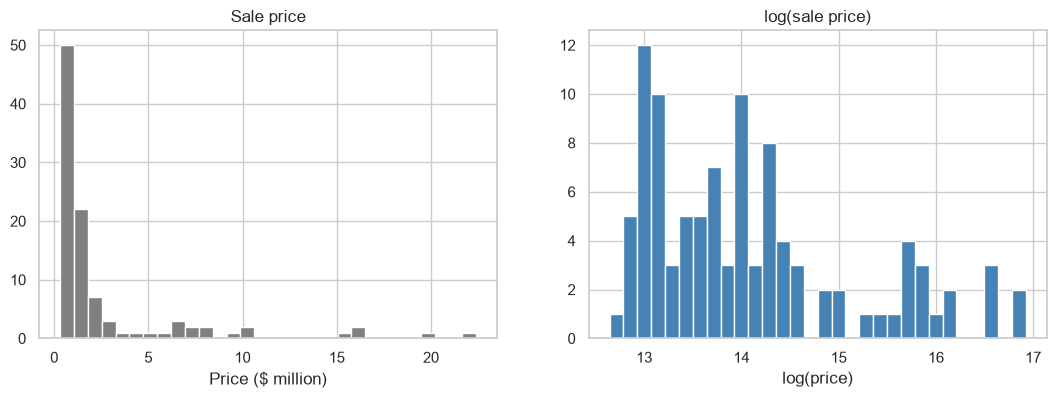

Mean price:  $2,700,317
Median price: $1,105,000
Skewness of price: 2.8
Skewness of log(price): 0.95


In [85]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(df["Price"] / 1e6, bins=30, color="grey")
ax[0].set_title("Sale price")
ax[0].set_xlabel("Price ($ million)")

ax[1].hist(np.log(df["Price"]), bins=30, color="steelblue")
ax[1].set_title("log(sale price)")
ax[1].set_xlabel("log(price)")
plt.show()

print("Mean price:  ${:,.0f}".format(df["Price"].mean()))
print("Median price: ${:,.0f}".format(df["Price"].median()))
print("Skewness of price:", round(df["Price"].skew(), 2))
print("Skewness of log(price):", round(np.log(df["Price"]).skew(), 2))

**What I found.** Prices are very **right-skewed**. Most properties sold for under \$2M, but a few Vaucluse homes sold for over \$10M. That pulls the mean (\$2.70M) to more than double the median (\$1.10M). Taking the **log of price** makes the distribution much more even (skewness drops from 2.80 to 0.95).

**Decision:** the models will predict `log(price)`. Otherwise the \$22M house would dominate training. I convert the predictions back to dollars at the end.

### 2.2 Differences between suburbs

In [88]:
# Group property types into two simple groups: house (owns its land) or strata (unit, townhouse, villa)
df["IsHouse"] = df["Type"].isin(["House", "Semi/Duplex"]).astype(int)
df["Group"] = np.where(df["IsHouse"] == 1, "House", "Strata")

print("Median sale price by suburb:")
print(df.groupby("Suburb")["Price"].median().reindex(SUBURBS))
print()
print("Median sale price by suburb and group:")
pd.pivot_table(df, index="Suburb", columns="Group", values="Price", aggfunc=["median", "count"]).reindex(SUBURBS)

Median sale price by suburb:
Suburb
Mount Druitt     840000.0
Cabramatta       552500.0
Vaucluse        3170000.0
Name: Price, dtype: float64

Median sale price by suburb and group:


median            count       
Group             House     Strata House Strata
Suburb                                         
Mount Druitt  1105000.0   482500.0    13     18
Cabramatta    1650000.0   495000.0    13     23
Vaucluse      7950000.0  1400000.0    17     17

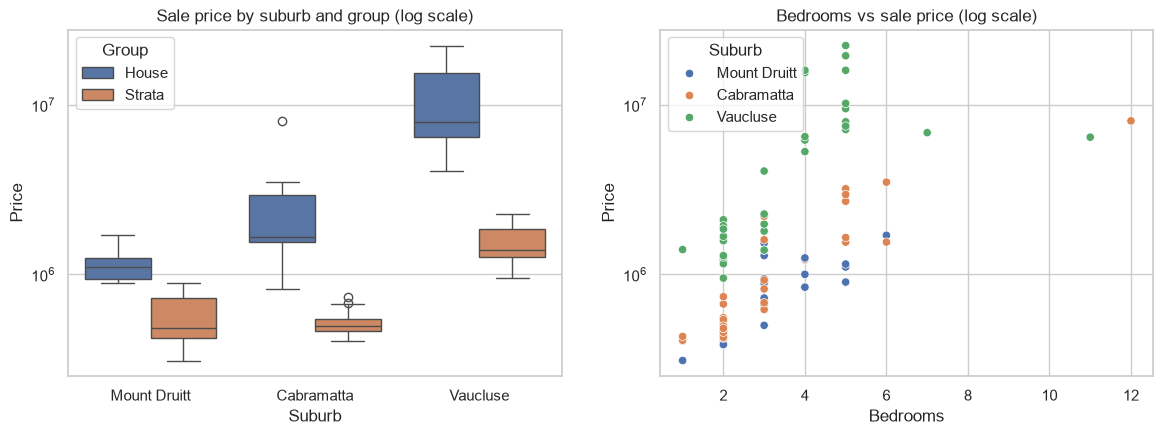

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df, x="Suburb", y="Price", hue="Group", order=SUBURBS, ax=ax[0])
ax[0].set_yscale("log")
ax[0].set_title("Sale price by suburb and group (log scale)")

sns.scatterplot(data=df, x="Bedrooms", y="Price", hue="Suburb", hue_order=SUBURBS, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Bedrooms vs sale price (log scale)")
plt.show()

**What I found.**
- **Vaucluse is in a different league.** A typical Vaucluse house (\$7.95M) costs about **7 times** a typical Mount Druitt house (\$1.11M). Its units (\$1.40M) cost about 3 times more than Mount Druitt units.
- **Suburb medians on their own can mislead.** Cabramatta's overall median (\$553k) is *lower* than Mount Druitt's (\$840k), but that's only because most of the Cabramatta sales I collected are units. Comparing like with like, Cabramatta houses (\$1.65M) cost about 50% more than Mount Druitt houses, and units in both suburbs sell for about the same (\$0.48–0.50M). **So suburb and property type need to be looked at together.**
- **More bedrooms means a higher price in every suburb**, but the points for Vaucluse sit much higher and rise faster.

The tool has to know both *where* the property is and *what kind* of property it is. Neither one is enough on its own.

### 2.3 Trends over time

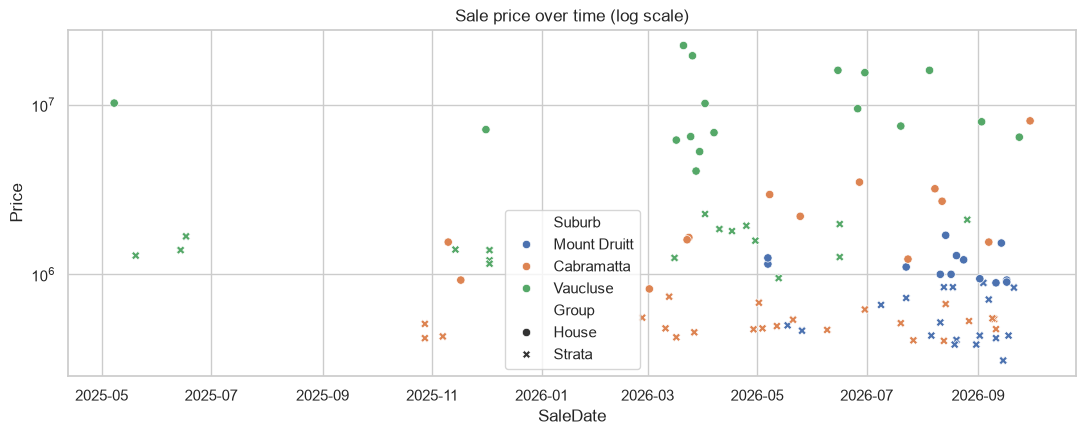

Quarter                  2025Q2     2025Q4     2026Q1      2026Q2     2026Q3
Suburb       Group                                                          
Cabramatta   House          NaN  1237500.0  1600000.0   2958000.0  2700000.0
             Strata         NaN   430000.0   480000.0    495000.0   522500.0
Mount Druitt House          NaN        NaN        NaN   1200000.0  1000000.0
             Strata         NaN        NaN        NaN    482500.0   477500.0
Vaucluse     House   10250000.0  7150000.0  6350000.0  10200000.0  7725000.0
             Strata   1390000.0  1300000.0  1250000.0   1825000.0  2100000.0

In [92]:
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.scatterplot(data=df, x="SaleDate", y="Price", hue="Suburb", style="Group", hue_order=SUBURBS, ax=ax)
ax.set_yscale("log")
ax.set_title("Sale price over time (log scale)")
plt.show()

# Median price per quarter, comparing like with like (same suburb and group)
df["Quarter"] = df["SaleDate"].dt.to_period("Q")
pd.pivot_table(df, index=["Suburb", "Group"], columns="Quarter", values="Price", aggfunc="median")

**What I found.**
- My sales are **not spread evenly over time**. The early sales (2025) are mostly Vaucluse, and Mount Druitt only starts in May 2026. Looking at all the data together would be misleading, because later sales look "cheaper" only because more of them are from Mount Druitt.
- Comparing like with like, there's a **small upward trend**. For example, Cabramatta units went from about \$430k (late 2025) to \$523k (mid 2026), and Vaucluse units from about \$1.3M to \$2.1M. But each quarter only has a few sales, so I can't be sure how much of this is the market and how much is just different properties.
- The change over time is **small compared with the gaps between suburbs and property types**, so I don't use sale date as a model feature. This also keeps the app simpler.

### 2.4 Unusual observations and outliers
A \$10M sale is normal in Vaucluse but would be extreme in Mount Druitt, so I look for outliers **inside each suburb and group**. I use the standard IQR rule: anything below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is flagged. I also look for strange feature values.

In [95]:
def is_outlier(prices):
    q1 = prices.quantile(0.25)
    q3 = prices.quantile(0.75)
    iqr = q3 - q1
    return (prices < q1 - 1.5 * iqr) | (prices > q3 + 1.5 * iqr)

df["Outlier"] = df.groupby(["Suburb", "Group"])["Price"].transform(is_outlier)

cols = ["ID", "Suburb", "Type", "Price", "Bedrooms", "Bathrooms", "Cars", "Land", "Notes"]
print("Price outliers within their suburb and group:")
display(df.loc[df["Outlier"], cols])

print("Unusual feature values (more than 6 car spaces or more than 7 bedrooms):")
display(df.loc[(df["Cars"] > 6) | (df["Bedrooms"] > 7), cols])

Price outliers within their suburb and group:


,ID,Suburb,Type,Price,Bedrooms,Bathrooms,Cars,Land,Notes
0,1,Cabramatta,House,8050000,12,5,22.0,1370.0,multi-lot / multi-dwelling sale; two adjoining...
51,52,Cabramatta,Townhouse,738000,2,1,1.0,NaN,NaN
86,87,Cabramatta,Unit/Apartment,680000,3,2,1.0,NaN,agency not shown on page


Unusual feature values (more than 6 car spaces or more than 7 bedrooms):


,ID,Suburb,Type,Price,Bedrooms,Bathrooms,Cars,Land,Notes
0,1,Cabramatta,House,8050000,12,5,22.0,1370.00,multi-lot / multi-dwelling sale; two adjoining...
26,27,Mount Druitt,House,1700000,6,3,10.0,1012.00,NaN
34,35,Vaucluse,House,6450000,11,5,NaN,696.77,car spaces not shown; land size taken from des...
100,101,Mount Druitt,House,1250000,4,2,7.0,763.00,NaN


**What I found and what I decided**

| ID | What's unusual | Decision |
|---|---|---|
| 1 | Two houses in Cabramatta sold together as a development site for \$8.05M (12 beds, 22 car spaces, 1,370 m²) | Real sale, **keep**, but cap car spaces at 6 |
| 52 | \$738k Cabramatta townhouse, high compared with the mostly-unit strata group | Real sale (townhouses are bigger than units), **keep** |
| 87 | \$680k 3-bedroom Cabramatta unit, at the top of the unit group | Real sale, **keep** |
| 35 | Four Vaucluse apartments sold together (11 bedrooms) | Real sale, **keep** |
| 27, 101 | 10 and 7 car spaces | Plausible on 1,012 m² and 763 m² blocks, **keep** but cap at 6 |

None of the prices look like typing mistakes, so I **keep all 101 properties**. Removing rows would also take me below the 100 required. Using log price and capping car spaces stops these few properties from having too much effect. I'll see in Part 4 whether they cause big errors.

The \$22.41M Vaucluse house (ID 93) is the most expensive in the data, but it isn't flagged, because the Vaucluse house prices are so spread out.

### 2.5 The three variables I expect to matter most (decided *before* feature engineering)

1. **Suburb (location).** The land is where the value is, and land value depends on location: distance to the city, the water, transport. The box plot showed prices going from entry level to luxury across the three suburbs.
2. **Property type (house or strata).** A house owns its land, while a unit only owns a share. In Sydney that should create a big price jump within every suburb.
3. **Bedrooms (size).** Building size is mostly missing, so bedrooms is the best measure I have of how big the home is.

I also expect these to **work together**: being a house, or having an extra bedroom, should be worth much more in Vaucluse than in Mount Druitt.

### 2.6 Feature engineering
Models need numbers, so I turn the raw columns into numeric features. I keep the features simple so that the **app can make exactly the same features** from what a user types in.

| Feature | How it's made | Why |
|---|---|---|
| `Cabramatta`, `Vaucluse` | 1 if the property is in that suburb (Mount Druitt is when both are 0) | Turns suburb into numbers (one-hot encoding) |
| `IsHouse` | 1 for House or Semi/Duplex, 0 for unit/townhouse/villa | Owning land vs strata, my 2nd key variable |
| `Bedrooms`, `Bathrooms` | As collected | Size of the home |
| `Cars` | Missing = 1 (the most common value), capped at 6 | Parking, without the 22-car-space development site distorting things |
| `LogLand` | Strata = 0 m². A house with missing land gets that suburb's median house land size. Then log(1 + land) | Makes land usable even though it's often missing |
| `Extras` | Count of Yes answers for pool, air con, renovated, views, study, outdoor space | Each Yes/No is noisy, but the total gives a sense of how "high spec" the property is |
| `kw_water`, `kw_luxury`, `kw_develop`, `kw_investor` | 1 if the agent's description contains certain keywords | Uses the **text data**: views/water, luxury language, development potential, investor/first-home-buyer language |

In [99]:
# Median land size of HOUSES in each suburb (used to fill missing land sizes)
LAND_MEDIANS = df[df["IsHouse"] == 1].groupby("Suburb")["Land"].median().to_dict()
print("Median house land size (m²):", LAND_MEDIANS)

# Keywords searched for in the agent description
KEYWORDS = {
    "kw_water":    "harbour|ocean|beach|water view|waterfront",
    "kw_luxury":   "luxur|prestige|architect|designer|bespoke",
    "kw_develop":  "develop|granny|dual occ|subdivi|zoning",
    "kw_investor": "invest|rental|first home",
}

YES_NO = ["Pool", "Air Con", "Renovated", "Views", "Study", "Outdoor Space"]


def make_features(data):
    # Turn raw property details into the numeric features the model uses.
    # The app (app/app.py) uses this exact same function.
    X = pd.DataFrame(index=data.index)
    X["Cabramatta"] = (data["Suburb"] == "Cabramatta").astype(int)
    X["Vaucluse"] = (data["Suburb"] == "Vaucluse").astype(int)
    X["IsHouse"] = data["Type"].isin(["House", "Semi/Duplex"]).astype(int)
    X["Bedrooms"] = data["Bedrooms"]
    X["Bathrooms"] = data["Bathrooms"]
    X["Cars"] = data["Cars"].fillna(1).clip(upper=6)

    land = data["Land"].fillna(data["Suburb"].map(LAND_MEDIANS))   # fill missing house land
    land = land.where(X["IsHouse"] == 1, 0)                         # strata has no private land
    X["LogLand"] = np.log1p(land)

    X["Extras"] = (data[YES_NO] == "Yes").sum(axis=1)

    text = data["Description"].fillna("").str.lower()
    for name, words in KEYWORDS.items():
        X[name] = text.str.contains(words).astype(int)
    return X


X = make_features(df)
y = np.log(df["Price"])          # target = log(price), as decided in 2.1
FEATURES = list(X.columns)
X.head()

Median house land size (m²): {'Cabramatta': 560.0, 'Mount Druitt': 700.0, 'Vaucluse': 696.77}


,Cabramatta,Vaucluse,IsHouse,Bedrooms,Bathrooms,Cars,LogLand,Extras,kw_water,kw_luxury,kw_develop,kw_investor
0,1,0,1,12,5,6.0,7.223296,1,0,0,1,0
1,0,0,0,4,2,2.0,0.000000,2,0,0,0,1
2,0,0,0,2,1,1.0,0.000000,2,0,0,0,1
3,0,0,1,3,1,2.0,6.122493,2,0,0,1,1
4,0,0,1,5,3,5.0,6.298949,3,0,0,0,0


In [100]:
# How often does each keyword appear in each suburb?
kw_cols = list(KEYWORDS)
(X[kw_cols].groupby(df["Suburb"]).mean() * 100).round(0).reindex(SUBURBS)

,kw_water,kw_luxury,kw_develop,kw_investor
Suburb,,,,
Mount Druitt,0.0,6.0,26.0,71.0
Cabramatta,0.0,25.0,8.0,75.0
Vaucluse,82.0,56.0,6.0,18.0


### 2.7 Do the features behave the way I expected?
I check the correlation of each feature with log(price) in two ways:
1. **All properties together.** Here suburb differences dominate everything.
2. **Inside each suburb separately.** This shows whether a feature still helps once we already know the suburb.

,All properties,Mount Druitt,Cabramatta,Vaucluse
Bathrooms,0.75,0.56,0.91,0.81
kw_water,0.70,NaN,NaN,0.38
LogLand,0.69,0.81,0.89,0.93
IsHouse,0.68,0.80,0.87,0.92
Bedrooms,0.65,0.82,0.89,0.69
kw_luxury,0.59,0.37,0.66,0.36
Extras,0.52,0.46,0.21,0.65
Cars,0.48,0.61,0.92,0.75
kw_develop,0.10,0.61,0.51,0.03
kw_investor,-0.62,-0.18,-0.49,-0.54


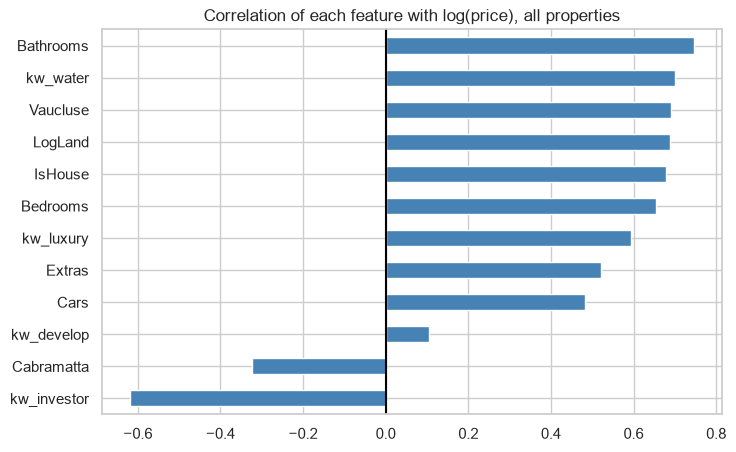

In [102]:
overall = X.corrwith(y)

within = {}
for suburb in SUBURBS:
    rows = df["Suburb"] == suburb
    within[suburb] = X[rows].drop(columns=["Cabramatta", "Vaucluse"]).corrwith(y[rows])

corr_table = pd.DataFrame(within)
corr_table.insert(0, "All properties", overall)
corr_table = corr_table.round(2)
display(corr_table.sort_values("All properties", ascending=False))

overall.sort_values().plot.barh(figsize=(8, 5), color="steelblue")
plt.title("Correlation of each feature with log(price), all properties")
plt.axvline(0, color="black")
plt.show()

### 2.8 Does the feature engineering match what I expected?

**Mostly yes.**
- **Suburb:** confirmed. `Vaucluse` is one of the strongest features overall (0.69). `kw_water` is also high (0.70), but that's mostly because water words almost only appear in Vaucluse listings (82% of them, and 0% elsewhere). So it's mostly repeating the suburb.
- **Property type:** confirmed. Inside each suburb, `IsHouse` is very strong (0.80–0.92). This is the house vs unit jump I expected.
- **Bedrooms / size:** confirmed, with a small surprise. Bedrooms is strong (0.65 overall, 0.69–0.89 inside suburbs), but **bathrooms (0.75) and land size (0.69) are just as strong or stronger**. They all describe the same thing ("a bigger house on its own land"), so they're **highly correlated with each other**. That matters for the linear model in Part 3.
- **Text features add something extra:** luxury language goes with higher prices (0.36–0.66 within suburbs), and investor / first-home-buyer language goes with cheaper properties (−0.18 to −0.54). That supports using the agent descriptions.
- **Weaker than expected:** `Extras` is weak in Cabramatta (0.21), probably because "No" often just means "not mentioned".

The data backs up what agents already know. Location and house vs unit set the price level, and size and quality move it up or down from there. The model learns how much each one is worth from real sales.

---
## Part 3: Model Development and Evaluation

### 3.1 Which models and why (written before training)
I compare three models from **different families**:

| | **Ridge regression** | **Random forest** | **Gradient boosting** |
|---|---|---|---|
| Type | Linear model with a penalty (L2) | Many decision trees, averaged | Trees built one after another, each fixing the last one's mistakes |
| Why it suits my data | Simple and quick, and works with small data. The penalty helps with my correlated size features (bedrooms, bathrooms, land) | Learns combinations automatically (e.g. "Vaucluse **and** house"), and averaging many trees makes it stable and less affected by outliers | Often the most accurate model on table data, and can learn complex patterns |
| Weaknesses | Assumes every feature adds the same % to price in every suburb. Can **extrapolate** to silly prices for unusual inputs | **Can't predict above the highest prices it has seen**, so it will struggle with the most expensive homes | Has more settings to tune, and can **overfit** small datasets easily. It also can't extrapolate |

**My expectation:** I expect the **random forest to perform best**. My data has clear "combination" effects (a Vaucluse house is a completely different market from a Mount Druitt unit) and a few outliers. I expect gradient boosting to be close but to overfit with only 101 properties, and Ridge to be the weakest because it can't give each suburb its own effect for houses and bedrooms.

**How I evaluate:** **5-fold cross-validation** (shuffled, `random_state=42`). The data is split into 5 parts, and each model is trained on 4 parts and tested on the 5th, five times, so every property gets tested once. I report:
- **RMSE and R² on log(price).** RMSE on the log scale works roughly like a % error.
- **MAE in dollars**, which is the average dollar error an agent would see.
- **MAPE** (average % error) and **median % error**, which are fair across cheap units and \$20M homes.
- **Train vs test RMSE**, to check for underfitting and overfitting.

In [105]:
models = {
    "Ridge regression": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                   max_depth=3, random_state=42),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
actual = df["Price"]

results = []
predictions = {}
for name, model in models.items():
    # scores on the log scale, for both the training folds and the test folds
    scores = cross_validate(model, X, y, cv=kfold, return_train_score=True,
                            scoring=["neg_root_mean_squared_error", "r2"])

    # each property predicted by a model that did NOT see it in training -> convert back to dollars
    pred = np.exp(cross_val_predict(model, X, y, cv=kfold))
    predictions[name] = pred
    pct_error = np.abs(pred - actual) / actual * 100

    results.append({
        "Model": name,
        "Train RMSE (log)": -scores["train_neg_root_mean_squared_error"].mean(),
        "Test RMSE (log)": -scores["test_neg_root_mean_squared_error"].mean(),
        "Test R² (log)": scores["test_r2"].mean(),
        "MAE ($)": np.mean(np.abs(pred - actual)),
        "MAPE (%)": pct_error.mean(),
        "Median % error": pct_error.median(),
    })

results = pd.DataFrame(results).set_index("Model")
results["Gap (test - train)"] = results["Test RMSE (log)"] - results["Train RMSE (log)"]
results.round(3)

,Train RMSE (log),Test RMSE (log),Test R² (log),MAE ($),MAPE (%),Median % error,Gap (test - train)
Model,,,,,,,
Ridge regression,0.279,0.337,0.890,1060005.623,25.240,15.389,0.058
Random forest,0.134,0.303,0.901,860076.580,19.013,12.241,0.170
Gradient boosting,0.071,0.306,0.906,1021349.385,19.678,12.619,0.235


**Results.**
- The **random forest is the best on every test metric**: test RMSE 0.303 on the log scale, R² 0.90, an average error of about \$860k, 19.0% average error and **12.2% median error**. So for a typical property, it's within about 12% of the real price.
- **Gradient boosting** is very close on the log scale (0.306), but its dollar error is higher (\$1.02M), because it sometimes over-predicts expensive Vaucluse homes by a lot (see the plots below).
- **Ridge** is the weakest (test RMSE 0.337, 25.2% average error, \$1.06M MAE).

For an ordinary property the estimate is usually within about 10–15%. For a top-end home the error can be millions of dollars, so the app needs to be honest about that.

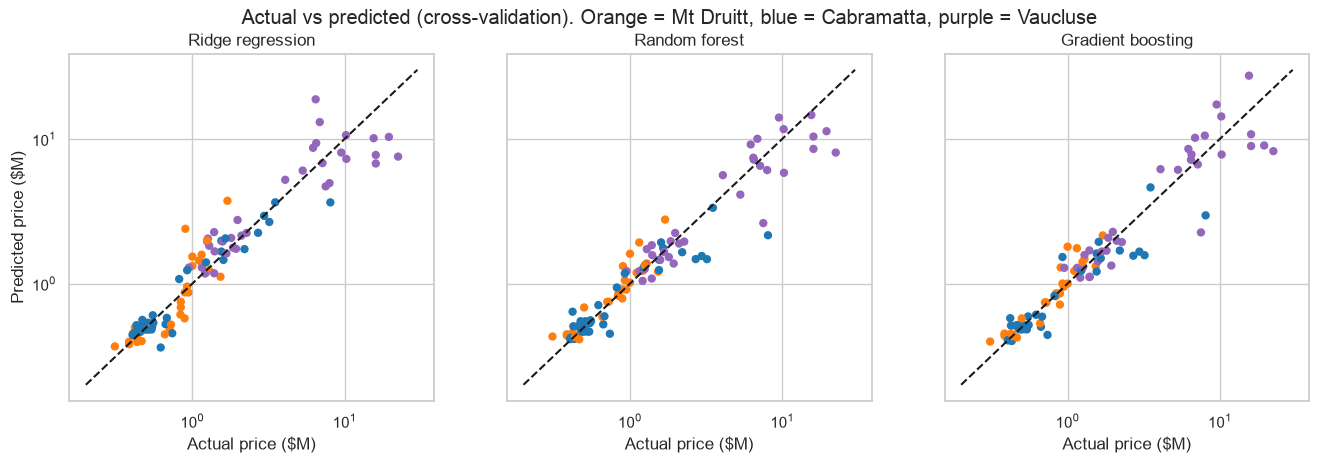

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
colours = df["Suburb"].map({"Mount Druitt": "tab:orange", "Cabramatta": "tab:blue", "Vaucluse": "tab:purple"})

for ax, name in zip(axes, models):
    ax.scatter(actual / 1e6, predictions[name] / 1e6, c=colours, s=25)
    ax.plot([0.2, 30], [0.2, 30], "k--")            # perfect prediction line
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel("Actual price ($M)")
axes[0].set_ylabel("Predicted price ($M)")
plt.suptitle("Actual vs predicted (cross-validation). Orange = Mt Druitt, blue = Cabramatta, purple = Vaucluse")
plt.show()

**What the plots show.**
- All three models are good for the cheaper properties (the points sit close to the dashed line).
- **Ridge has the widest spread** and makes some huge over-predictions. For example, it predicts about \$18.7M for ID 35 (four Vaucluse apartments sold together for \$6.45M), because 11 bedrooms × the Vaucluse price level gives a silly number. This is the extrapolation problem I expected.
- **The tree models hit a "ceiling"** at around \$10–12M. They under-predict every sale above \$15M, because a tree can only predict averages of prices it has already seen.

### 3.2 Underfitting, overfitting and model complexity
To see how complexity changes things, I change one setting for each tree model and compare train vs test error:
- Random forest: `max_depth` (deeper trees = more complex)
- Gradient boosting: `n_estimators` (more trees = more complex)

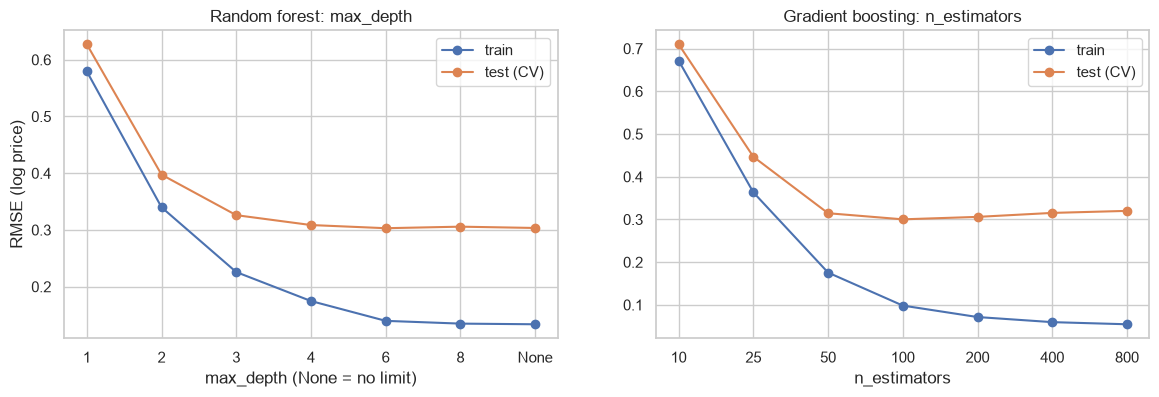

In [110]:
depths = [1, 2, 3, 4, 6, 8, None]
rf_train, rf_test = [], []
for d in depths:
    s = cross_validate(RandomForestRegressor(n_estimators=300, max_depth=d, random_state=42), X, y,
                       cv=kfold, scoring="neg_root_mean_squared_error", return_train_score=True)
    rf_train.append(-s["train_score"].mean())
    rf_test.append(-s["test_score"].mean())

n_trees = [10, 25, 50, 100, 200, 400, 800]
gb_train, gb_test = [], []
for n in n_trees:
    s = cross_validate(GradientBoostingRegressor(n_estimators=n, learning_rate=0.05, max_depth=3, random_state=42),
                       X, y, cv=kfold, scoring="neg_root_mean_squared_error", return_train_score=True)
    gb_train.append(-s["train_score"].mean())
    gb_test.append(-s["test_score"].mean())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
labels = [str(d) for d in depths]
ax[0].plot(labels, rf_train, "o-", label="train")
ax[0].plot(labels, rf_test, "o-", label="test (CV)")
ax[0].set_title("Random forest: max_depth")
ax[0].set_xlabel("max_depth (None = no limit)")
ax[0].set_ylabel("RMSE (log price)")
ax[0].legend()

ax[1].plot([str(n) for n in n_trees], gb_train, "o-", label="train")
ax[1].plot([str(n) for n in n_trees], gb_test, "o-", label="test (CV)")
ax[1].set_title("Gradient boosting: n_estimators")
ax[1].set_xlabel("n_estimators")
ax[1].legend()
plt.show()

**What this shows.**
- **Underfitting:** very simple versions are bad on *both* train and test. A random forest with depth 1 has a train RMSE of 0.58 and a test RMSE of 0.63, and gradient boosting with 10 trees is similar. They're too simple to learn suburb + type + size.
- **Random forest:** the test error improves up to about depth 4–6 (≈ 0.30) and then stays flat. The training error keeps dropping (to 0.13), so there's a big train–test gap (0.17), but the test error **doesn't get worse**. Averaging 300 trees cancels out most of the overfitting.
- **Gradient boosting:** this is the clearest **overfitting**. The test error is best at about 100 trees (0.30), then gets worse (0.32 at 800 trees), while the training error goes almost to zero (0.055). It starts memorising individual sales. My setting of 200 trees has the largest train–test gap of the three (0.24).
- **Ridge** has the smallest gap (train 0.28 vs test 0.34). It doesn't overfit much, but it slightly **underfits**, because one straight-line rule can't describe three very different markets.
- **Overall:** going from simple to more complex helps up to a point. After that, the problem isn't the model. It's **how much information is in 101 properties**.

### 3.3 Revisiting my expectations and recommendation
- ✔ **Random forest was best**, as I expected.
- ✔ **Gradient boosting overfit the most**: the biggest train–test gap, and the test error went up when I added more trees.
- ✔ **Ridge was the weakest**, but the reason surprised me. On the log scale it wasn't far behind. Its real problem was a few **wildly wrong predictions** on unusual properties (like \$18.7M for a \$6.45M sale), which hurt the dollar metrics.

**Recommendation: random forest.** I'd deploy the random forest because:
1. it has the **lowest error on every test metric**;
2. it **fails safely**. It can't produce crazy numbers like Ridge's \$18.7M, because its predictions always stay inside the range of real sale prices. That's important when agents might type in unusual properties;
3. it **doesn't get worse when it's more complex**, so I don't need much tuning;
4. its main weakness (under-predicting the most expensive homes) is something I can warn users about. I look at it in Part 4.

---
## Part 4: Investigating Prediction Failures
I use the random forest's cross-validation predictions, so **every property was predicted by a model that never saw it**. These are honest errors.

In [114]:
errors = df[["ID", "Suburb", "Type", "Bedrooms", "Bathrooms", "Cars", "Land", "Views", "Notes"]].copy()
errors["Actual"] = actual
errors["Predicted"] = predictions["Random forest"].round(-3)
errors["Error ($)"] = errors["Predicted"] - errors["Actual"]
errors["Error (%)"] = (errors["Error ($)"] / errors["Actual"] * 100).round(0)

top5 = errors.reindex(errors["Error ($)"].abs().sort_values(ascending=False).index).head(5)
top5

,ID,Suburb,Type,Bedrooms,Bathrooms,Cars,Land,Views,Notes,Actual,Predicted,Error ($),Error (%)
92,93,Vaucluse,House,5,3,2.0,680.0,Yes,land size taken from description,22410000,8039000.0,-14371000.0,-64.0
94,95,Vaucluse,House,5,4,4.0,1173.0,No,land size taken from description; pasted 2x in...,19500000,11290000.0,-8210000.0,-42.0
36,37,Vaucluse,House,5,4,2.0,775.0,Yes,"DA approved for a pool, not yet built",16000000,8522000.0,-7478000.0,-47.0
0,1,Cabramatta,House,12,5,22.0,1370.0,No,multi-lot / multi-dwelling sale; two adjoining...,8050000,2158000.0,-5892000.0,-73.0
71,72,Vaucluse,House,4,3,2.0,883.0,Yes,NaN,16000000,10370000.0,-5630000.0,-35.0


In [115]:
total_error = errors["Error ($)"].abs().sum()
print("Share of the total dollar error from these 5 properties: {:.0%}".format(top5["Error ($)"].abs().sum() / total_error))
print()

# Read part of the agent description for each of the 5 properties
for i in top5.index:
    print("ID", df.loc[i, "ID"], "|", df.loc[i, "Address"])
    print(" ".join(df.loc[i, "Description"].split())[:350], "...")
    print()

Share of the total dollar error from these 5 properties: 48%

ID 93 | 44A Wentworth Road, Vaucluse NSW 2030
Modernist Architectural Residence With Dual Frontages, Pool & Breathtaking Views To Harbour Bridge And Opera House In a blue-chip position opposite harbourfront parkland and the foreshore walk to Neilsen Park, this contemporary family residence stands on approx. 680 sqm land with frontages to Wentworth Road and Vaucluse Road, two of the most presti ...

ID 95 | 10A Dalley Avenue, Vaucluse NSW 2030
Family Sanctuary Where Stunning Harbour Panoramas and Tranquility Unite Hidden from the street and wrapped in tranquility, this expansive family retreat unveils spectacular harbour vistas encompassing the city skyline, Opera House and Harbour Bridge. Spanning three stunning levels and a 1,173sqm landholding, the property radiates warmth, comfort an ...

ID 37 | 17 New South Head Road, Vaucluse NSW 2030
An Exceptional Vaucluse Residence with Sweeping Harbour Views Panoramic views of Sydn

Median absolute % error:
Suburb        Group 
Mount Druitt  House      8.0
              Strata     7.5
Cabramatta    House     20.0
              Strata     8.0
Vaucluse      House     38.0
              Strata    13.0
Name: Abs % error, dtype: float64


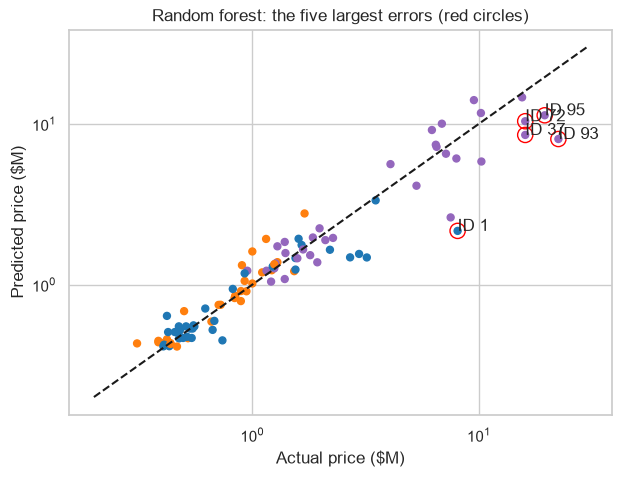

In [116]:
# How big are the errors for each suburb and group?
errors["Group"] = df["Group"]
errors["Abs % error"] = errors["Error (%)"].abs()
print("Median absolute % error:")
print(errors.groupby(["Suburb", "Group"])["Abs % error"].median().reindex(SUBURBS, level=0))

plt.figure(figsize=(7, 5))
plt.scatter(errors["Actual"] / 1e6, errors["Predicted"] / 1e6, c=colours, s=25)
plt.scatter(top5["Actual"] / 1e6, top5["Predicted"] / 1e6, s=120, facecolors="none", edgecolors="red")
for i in top5.index:
    plt.annotate("ID " + str(top5.loc[i, "ID"]), (top5.loc[i, "Actual"] / 1e6, top5.loc[i, "Predicted"] / 1e6))
plt.plot([0.2, 30], [0.2, 30], "k--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual price ($M)")
plt.ylabel("Predicted price ($M)")
plt.title("Random forest: the five largest errors (red circles)")
plt.show()

### 4.1 The five largest errors

| ID | Property | Actual → predicted | Why the model got it wrong |
|---|---|---|---|
| **93** | Vaucluse house, 5 bed, 680 m², Wentworth Rd | \$22.41M → \$8.04M (−64%) | The **most expensive sale in my data**. Its value comes from things I don't have as features: a top street with two frontages, direct **views to the Opera House and Harbour Bridge**, and a famous architect. On paper it looks like other 5-bed Vaucluse houses (e.g. ID 65, 5 bed, 694 m², \$7.5M). The forest also can't predict higher than the prices it has seen. |
| **95** | Vaucluse house, 5 bed, 1,173 m², Dalley Ave | \$19.50M → \$11.29M (−42%) | Harbour panorama to the Opera House and Bridge on a very big block. There's also a **data-entry mistake**: I recorded `Views` as "No", even though the description starts with "Stunning Harbour Panoramas". |
| **37** | Vaucluse house, 5 bed, 775 m², New South Head Rd | \$16.00M → \$8.52M (−47%) | Again panoramic harbour, Opera House and Bridge views. The family had owned it for 27 years, so it was a rare chance to buy. On paper (no pool, 2 car spaces) it looks *average* for Vaucluse. |
| **1** | Cabramatta, two houses sold together, 12 bed, 1,370 m² | \$8.05M → \$2.16M (−73%) | A **record-price development site** (R4 zoning) in the Cabramatta centre. The buyer paid for land and zoning, not bedrooms. It's the only sale like this in Cabramatta, so the model treats it like a big ordinary house. |
| **72** | Vaucluse house, 4 bed, 883 m², Wentworth Rd | \$16.00M → \$10.37M (−35%) | A grand older home ("Virginia") with uninterrupted harbour, Opera House and Bridge views on one of the best streets. Its exact location and view quality aren't captured. |

**The pattern:** these five properties make up **about half of all the model's dollar error**, and **all five were under-predicted**. Four of them are Vaucluse houses whose descriptions mention **Opera House / Harbour Bridge views**. My `kw_water` keyword treats "harbour", "ocean" and "beach" as the same thing, so it can't tell an iconic harbour view from a regular ocean glimpse.

### 4.2 Limitations of my approach
- **Tree models can't go above the highest prices they've seen**, so the most expensive homes are always under-predicted. Ridge *can* go higher, but in Part 3 it did so in silly ways. Neither works well at the top end with only ~100 sales.
- **Errors get bigger as prices go up.** Strata properties have a median error of about 7–13%. For houses it's 8% in Mount Druitt, 20% in Cabramatta and 38% in Vaucluse.
- **Small groups:** only 13–17 houses per suburb and 3 multi-dwelling sales, so the model has very few examples for these.
- **Keyword features are simple.** They check whether a word appears, not what it means. "Harbour views" and "walk to the harbour" look the same.

### 4.3 Information that wasn't available but would help
- **Exact location inside the suburb:** the street, distance to the water or station, which side of the peninsula (harbour vs ocean).
- **View quality:** harbour/Opera House vs ocean vs none.
- **Floor area, year built and condition.** These were missing from 83–98% of listings.
- **Zoning and development potential** (e.g. R4), which drove the ID 1 price.
- **Sale details:** auction or private sale, number of bidders, days on market.
- **Listing photos**, which show the quality of the finish and the outlook.

### 4.4 When to be careful with predictions
- **Prestige homes over about \$10M**: the model has a ceiling, and errors can be 30–60%.
- **Development sites and multiple dwellings sold together**: these are valued on land and zoning, not bedrooms.
- **Rare property types** (villas, semis), very large homes or very large blocks.
- **Any other suburb**, or dates well after September 2026, since the market changes.

### 4.5 Are some properties harder to predict than others?
**Yes.** **Standard units are the easiest.** There are lots of similar sales, and their price mostly depends on things we can measure (bedrooms, bathrooms, parking). **Unique, high-value houses and development sites are the hardest.** Their price depends on one-off things (a particular view, street or zoning) and on how many buyers are competing, and there are very few similar sales. Even a professional valuer relies on judgement for these.


---
## Part 5: Final Deployment and Reflection

### 5.1 Train the final model and save it for the app
The final random forest is trained on **all 101 properties** and saved with `joblib`. I also save the feature list, the land medians and the keywords, so the app makes the features the same way, plus the model's typical % error to show users.

In [119]:
final_model = RandomForestRegressor(n_estimators=300, random_state=42)
final_model.fit(X, y)

typical_error = results.loc["Random forest", "Median % error"]

joblib.dump({"model": final_model,
             "features": FEATURES,
             "land_medians": LAND_MEDIANS,
             "keywords": KEYWORDS,
             "typical_error": typical_error},
            "app/model.joblib")
print("Saved app/model.joblib")

# Quick test: predict one property the same way the app does
example = pd.DataFrame([{"Suburb": "Cabramatta", "Type": "House", "Bedrooms": 4, "Bathrooms": 2, "Cars": 2,
                         "Land": 560, "Pool": "No", "Air Con": "Yes", "Renovated": "No", "Views": "No",
                         "Study": "No", "Outdoor Space": "Yes", "Description": ""}])
print("Example 4-bed Cabramatta house: ${:,.0f}".format(np.exp(final_model.predict(make_features(example))[0])))

Saved app/model.joblib
Example 4-bed Cabramatta house: $1,132,100


### 5.2 The web app
I built the app with **Streamlit** (`app/app.py`). Streamlit lets you build a web page using only Python, which makes sense for a student startup with no front-end developer.

**How it was developed**
1. **Model:** the notebook saves the trained random forest and everything the app needs into `app/model.joblib` (cell above).
2. **Same features:** the app has a copy of `make_features()` from Part 2, so what a user types in becomes exactly the same 13 features the model was trained on.
3. **Input form:** the agent chooses the suburb and property type, enters bedrooms, bathrooms, car spaces and land size, ticks the extra features, and can paste the agent description (used for the keyword features).
4. **Output:** after clicking **Estimate price**, the app shows the predicted price (converted back from log price to dollars), plus a note on how accurate the model usually is (about ±12% for a typical property) and a warning that prestige homes and development sites are harder to predict.
5. **Deployment:** the code is on GitHub(https://github.com/chakriyathida/sydney-housing-price) and the app is hosted on Streamlit Community Cloud(https://sydney-housing-price-xth7rckooif6tdmgmtsldy.streamlit.app/).

Screenshot 1: the input form


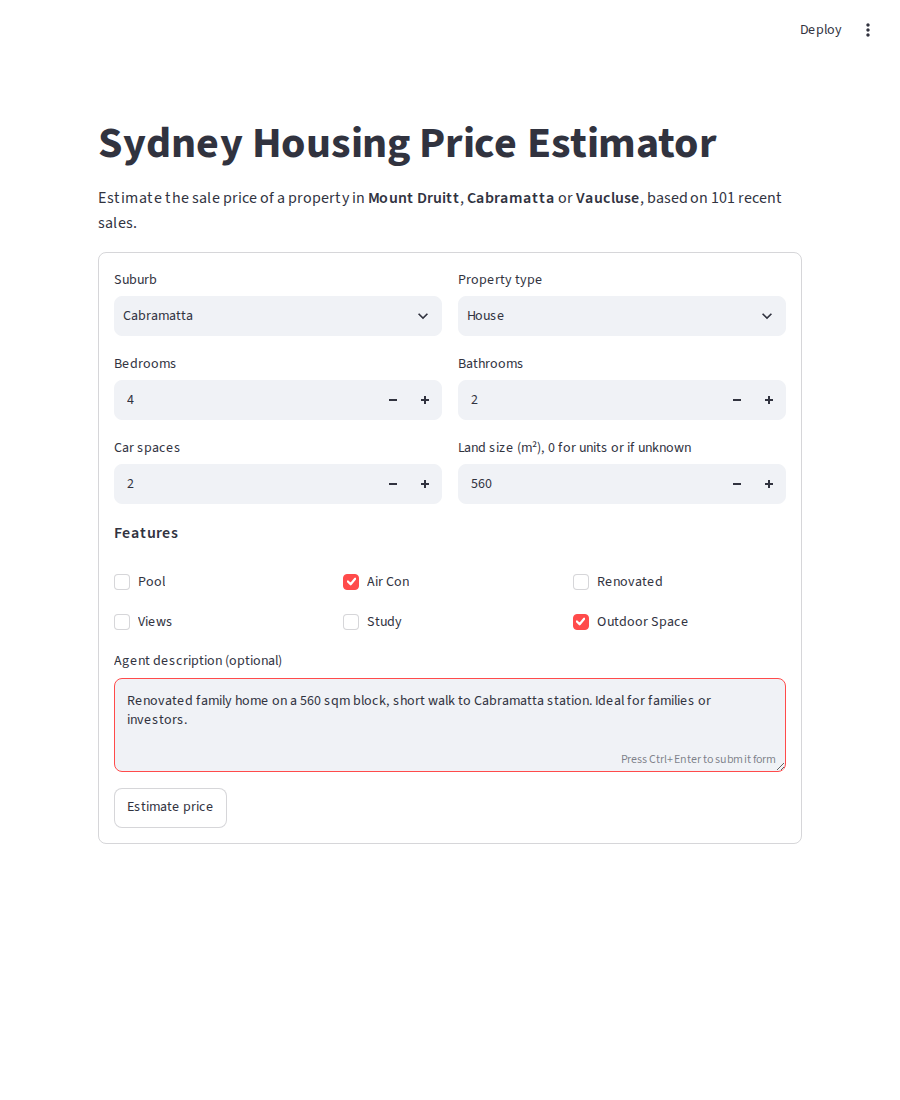

Screenshot 2: the predicted price


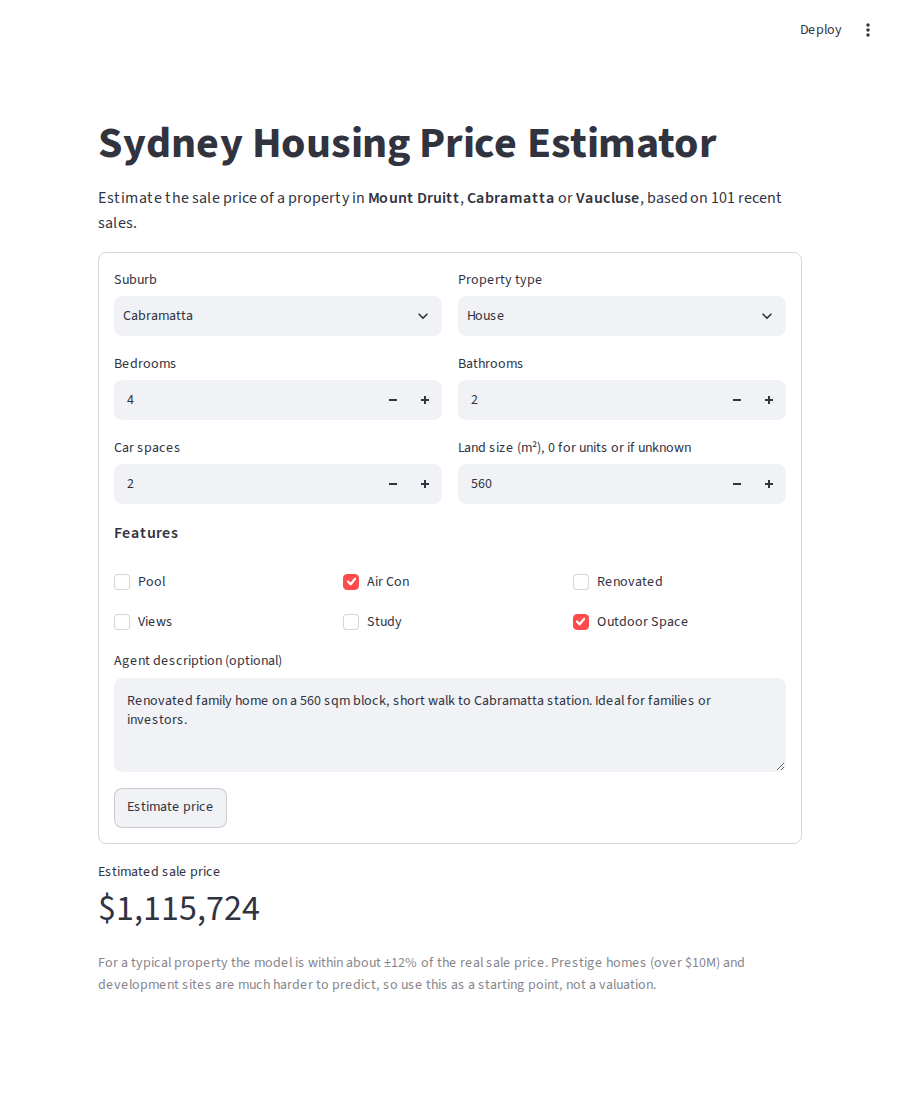

In [121]:
from IPython.display import Image
print("Screenshot 1: the input form")
display(Image(filename="app/screenshots/1_form.png", width=700))
print("Screenshot 2: the predicted price")
display(Image(filename="app/screenshots/2_prediction.png", width=700))

### 5.3 How to use the app 

1. Choose the **suburb** and **property type**.
2. Enter **bedrooms, bathrooms, car spaces** and **land size** (leave land as 0 for units, or if you don't know it).
3. Tick any **features** the property has (pool, air con, renovated, views, study, outdoor space).
4. *(Optional)* Paste the **agent description**.
5. Click **Estimate price** to see the estimated sale price.

### 5.4 Reflection

**Key lessons**
- **Understanding the data mattered more than the choice of model.** The biggest improvements came from Part 2 decisions: predicting log price, looking at suburb and property type together, and handling land size properly for units. In the end, the three models were within about 0.03 log RMSE of each other.
- **One number can hide a lot.** Ridge didn't look too bad on log RMSE, but in dollars a few crazy predictions made it the worst. Looking at several metrics and the actual vs predicted plots showed this.
- **The worst predictions taught me the most.** They exposed a data-entry mistake (ID 95's `Views`), a missing value driver (iconic harbour views) and the price ceiling of tree models.

**Challenges at each stage**
- *Data collection:* copying by hand from two websites, withheld prices, duplicates and a wrong link, and fields like floor area and year built that are hardly ever shown.
- *Preprocessing:* deciding what "land size" means for units (I used 0), and keeping unusual multi-dwelling sales without letting them distort the model.
- *Feature engineering:* with only three suburbs, location features like `kw_water` just repeated the suburb. Keyword features helped, but they're blunt.
- *Model development and evaluation:* with only ~20 properties in each test fold, results change a bit depending on the split, and gradient boosting overfit easily.

**Performance vs practical deployment**
I didn't only pick the random forest because it had the lowest error. I also picked it because of *how* it fails: it never gives a silly price, it needs very little tuning, and it trains in seconds. The trade-off is that it under-predicts the most expensive homes and is harder to explain than a linear model. I also kept the features simple so a user can fill in the form in under a minute. Adding more inputs (like sale date or detailed text analysis) might help accuracy a little, but it would make the app harder to use. A real product would also need regular re-training as the market changes.

**Bias, fairness and limitations**
- **Sampling bias:** withheld prices (common at the top end), different collection dates for each suburb and a different mix of property types all affect what the model learns.
- **Fairness:** these suburbs are very different in income and cultural background. A model that learns "suburb = price level" could **reinforce existing gaps** between communities if it was used for things like lending decisions, and its accuracy isn't equal across groups (a median error of about 7.5% for Mount Druitt units vs 38% for Vaucluse houses). It should support an agent's judgement, not replace it.
- **Marketing bias in the text:** descriptions are written to sell. Words like "investor" describe how agents target buyers, not the property itself.
- **Validity:** 101 sales over 17 months can't represent all of Sydney or the future market.

**How I'd improve it with more data, time or resources**
- **More data:** hundreds of sales per suburb, more suburbs (so location features like distance to the CBD actually mean something), and official sales records (e.g. NSW Valuer General) to reduce selection bias.
- **Better location and view information:** exact address coordinates, distance to the water and station, and a harbour vs ocean view feature.
- **Better text and images:** proper text models (e.g. TF-IDF) instead of keywords, and image models using listing photos.
- **Better models:** prediction ranges instead of a single number, and a separate model for the prestige market.
- **Product:** automatic data collection, checks that catch errors like ID 95's `Views`, and scheduled re-training.

For everyday homes in these three suburbs, the tool gives a price estimate within about 12% in seconds, built from real sales. It's upfront about where it struggles (prestige and development sites), and that's exactly where the agent's experience is most valuable.

### GenAI acknowledgement
I used Claude (Anthropic) to suggest and debug code, and to edit my writing for grammar and clarity. I checked all of the code by running it, compared every number in the discussion with the outputs above, and rewrote the explanations in my own words. All decisions (suburb choice, data collection, features, model choice) and the final analysis are my own work.